<font size="6"> **ENG 07044 - Controle de Processos Industriais / DEQUI / UFRGS** </font>

<font size="5">
Chuveirto Turbinado: Tanque de mistrura, boiler e Tubulação Longa
</font>


         Prof. Dr. Jorge Otávio Trierweiler -- Jorge.Trierweiler@ufrgs.br


In [1]:
# Importação de pacotes
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as wg
import control.matlab as ml
from scipy import signal as sg
from scipy.integrate import solve_ivp
from math import sqrt

from plotly.subplots import make_subplots
import plotly.graph_objects as go

import plotly.io as pio
pio.templates.default = 'plotly_dark'
Opcoes = ['ggplot2', 'seaborn', 'simple_white', 'plotly',
         'plotly_white', 'plotly_dark', 'presentation', 'xgridoff',
         'ygridoff', 'gridon', 'none'];

%matplotlib inline

In [2]:
def Plota( x, Dados1, Dados2=None,  tit = 'Sinais', xlabel='Tempo', ylabel1 = 'Saídas', ylabel2 ='Entradas'):
    # Função para fazer os plotes usando o plotly
    # x -- vetor das abcissas -- normalmente tempo
    # Dados1 -- dicionário contendo os dados que serão plotados no primeiro subplot
    # Dados2 -- dicionário contendo os dados do segundo subplote -- quando for NONE será feito apenas um plote
    # tit é o título
    # xlabel 
    # ylabel
    
    if Dados2 == None:
        fig = make_subplots(1,1)
    else: 
        fig = make_subplots(2,1)
    
    str = list(Dados1.keys())
    for k in range(len(str)):
        stt ='spline'
        if str[k][0] == 'S':
            stt = 'hv'
        fig.add_trace(go.Scatter(name=str[k], x=x, y=Dados1[str[k]], line_shape = stt),1,1)
        
    if Dados2 != None:
        str = list(Dados2.keys())
        for k in range(len(str)):
            fig.add_trace(go.Scatter(name=str[k], x=x, y=Dados2[str[k]],line={'shape':'hv'}),2,1)
        
    fig.update_xaxes(matches='x')
    fig.update_xaxes(title_text= xlabel, row=2, col=1)
    fig.update_yaxes(title_text =ylabel2, row=2, col=1)
    fig.update_layout(height=500, width = 800,
            title={'text': tit,'y':0.85,'x':0.5,
            'xanchor': 'center', 'yanchor': 'top'},
            #xaxis_title = ylabel2,
            yaxis_title=  ylabel1, legend_title="Variáveis")
    fig.show() 

# Válvulas de controle

In [3]:
# modelo para a válvula de alimentação da corrente quente

def AlimentacaoQuente(xf,xq):
    t = 60*(xq**(8/5))
    n = -1*(-180 - 45*(xf**2) - 250*(xq**(16/5))*(xf**2) - 1180*(xq**(16/5)) + 60*sqrt(9*(xq**(16/5))*(xf**2) + 50*(xq**(32/5))*(xf**2)))
    d = 6552*(xq**(16/5))*(xf**2) + 648*(xf**2) + 16400*(xq**(32/5))*(xf**2) + 900*(xq**(16/5))*(xf**4) + 2500*(xq**(32/5))*(xf**4) + 81*(xf**4) + 55696*(xq**(32/5)) + 16992*(xq**(16/5)) + 1296
    Fq = t*sqrt(n/d)
    return Fq

In [4]:
# modelo para a válvula de alimentação da corrente fria

def AlimentacaoFria(xf,Fq):
    n = 2*xf*sqrt(125*xf*xf - Fq*Fq + 500) - xf*Fq
    d = (xf**2) + 4
    Ff = n/d
    return Ff

In [5]:
# modelo para a válvula de saída

def Saida(xs):
    n = 5*(xs**3)*(sqrt(30))*sqrt(-15*(xs**6) + sqrt(6625*(xs**12) + 640*(xs**6) + 16))
    d = 20*(xs**6) + 1
    Fs = n/d
    return Fs

# Boiler

In [6]:
# modelo para o aquecedor de passagem

def Boiler(t,Tq,
           Fq,Tf,Sa):
    
    # EDO -- Atenção -- foi alterado o valor que multiplica Sa por 3 em relação ao valor documentado
    return Fq*(Tf - Tq) + 300*Sa

# Tanque com aquecedor

In [7]:
# modelo para o balanço de massa do tanque

def Nivel(t,h,
          Ff,Fq,Fd,Fs):
    
    # EDO
    return (1/0.5)*(Ff + Fq + Fd - Fs)

In [8]:
# modelo para o tanque de aquecimento com mistura

def Tanque(t,Tt,
           Ff,Tf,Fq,Tq,Fd,Td,Sr,h):
    
    # EDO
    return (1/(0.5*h))*(Ff*(Tf-Tt) + Fq*(Tq-Tt) + Fd*(Td-Tt) + 80*Sr)

# Tubulação

In [9]:
# modelo para a tubulação de saída

def Tubulacao(t,Ts,
             Tt,Fs,Tinf):
    
    # EDO
    return (Fs/2.5)*(Tt-Ts) - 0.8*(((Tt-Tinf)*(Ts-Tinf)*(0.5*(Tt-Tinf) + 0.5*(Ts-Tinf)))**(1/3))

# Controladores

In [10]:
def OnOff(Uop, medido,minimo,maximo):
    if medido < minimo:
        Uop = 1
    elif medido > maximo:
        Uop = 0
    return Uop

In [11]:
def PID(SP, PV, j, I_int, D_int, dt, Kp, Ti, Td, b, c, N, U_bias, Umin, Umax, Method = 'Backward'):
    
    if Method == 'Backward':
        b1 = Kp*dt/Ti if Ti!=0 else 0.0
        b2 = 0.0
        ad = Td/(Td+N*dt)
        bd = Kp*Td*N/(Td+N*dt)
    elif Method == 'Forward':
        b1 = 0.0
        b2 = Kp*dt/Ti  if Ti!=0 else 0.0
        ad = 1-N*dt/Td if Td!=0 else 0.0
        bd = Kp*N   
    elif Method == 'Tustin':
        b1 = Kp*dt/2/Ti if Ti!=0 else 0.0
        b2 = b1
        ad = (2*Td-N*dt)/(2*Td+N*dt)
        bd = 2*Kp*Td*N/(2*Td+N*dt)   
    elif Method == 'Ramp':
        b1 = Kp*dt/2/Ti if Ti!=0 else 0.0
        b2 = b1
        ad = np.exp(-N*dt/Td) if Td!=0 else 0.0
        bd = Kp*Td*(1-ad)/dt
        
    # Derivative action 
    D = ad*D_int + bd*((c*SP[j]-PV[j]) - (c*SP[j-1]-PV[j-1]))
    
    # Integral action
    II = b1*(SP[j]-PV[j]) + b2*(SP[j-1]-PV[j-1])
    I = I_int + II                         
   
    # Proportional action
    P = Kp * (b*SP[j]-PV[j])
    
    # calculate the PID output
    Uop = U_bias + P + I + D

    # implement anti-reset windup
    if Uop < Umin:
        II = 0.0
        Uop = Umin
    if Uop > Umax:
        II = 0.0
        Uop = Umax
    I = I_int + II
    
    # return the controller output and PID terms
    return np.array([ Uop, I, D])

# Sistema

In [12]:
def ModelagemSistema(t,Y,
                    Sa, xf,xq,xs, Tf,Td,Tinf,Fd,Sr):
    N   = 50
    Vt  = 5
    UAt = 0.01
    Fq = AlimentacaoQuente(xf,xq)
    Ff = AlimentacaoFria(xf,Fq)
    Fs = Saida(xs)
    #print((Fq,Ff,Fs, Fs-Fq-Ff))
    
    Tq = Y[0]
    h  = Y[1]
    Tt = Y[2]
    #T = Y[3]
    
    EDOTq = Boiler(t,Tq,Fq,Tf,Sa)
    EDOh = Nivel(t,h,Ff,Fq,Fd,Fs)
    EDOTt = Tanque(t,Tt,Ff,Tf,Fq,Tq,Fd,Td,Sr,h)
    #EDOTs = Tubulacao(t,Ts,Tt,Fs,Tinf) # versão apresentada no arquivo word -- só que sem o tempo morto
    # a seguir a tubulação longa está implementada discretizando a tubulação -- nos mesmos moldes da implementação feita no arquivo 00_Introdução_Malhas_de_Controle
    return np.array([EDOTq,EDOh,EDOTt]+list((N-1)/Vt*(Fs*(Y[2:N+1]-Y[3:N+2])-UAt*(Y[3:N+2]-Tinf))))

# Malhas de nível, temperatura do boiler e Temperatura Tanque em automático

In [13]:
def Simulacao_MF1(SYS, Y0, UT, dt): 
    # Y0 = [Tq, h, Tt, Ts]
    # Modelo do sistema, vetor de valores iniciais, matriz de perturbações, intervalo de tempo
    # Versão com malha de inventório de nível e temperatura on-off para a temperatura de alimentação
    
    # Armazenamento dos dados resultantes da simulação
    tempoFinal = UT[-1,0] 
    TT = np.arange(start = 0, stop = tempoFinal+dt, step = dt, dtype='float') # instantes de tempo
    nt = np.size(TT)
    ny = 4
    id = [0,1,2,-1]
    # matriz para armazenar valores das variáveis de saída para cada instante de tempo inicializando com os valores 
    # relativos a condição incial, ou seja, Y0
    YY = np.ones((nt,ny))@np.diag(Y0[id])
    SP = np.ones((nt,ny))@np.diag(Y0[id])
    
    nu = np.size(UT,1)
    UU = np.zeros((nt,nu-1)) # matriz para armazenar valores das variáveis de entrada para cada instante de tempo

    # malhas de controle seguirão o seguinte padrão
    # 0 -- malha controle de temperatura do boiler -- controlador liga-desliga
    # 1 -- malha de nível h 
    # 2 -- malha de temperatura do tanque
    # 3 -- malha de vazão de saída
    
    
    # malhas de controle 
    #                    Tq,  h ,  T1, Ts
    Kp      = np.array([ 1, 0.3, 0.6, 0.5])
    Ti      = np.array([ 1, 0.8, 0.8, 0.5])
    Td      = np.array([ 1, 0.0, 0.0, 0.0])
    b       = np.array([ 1, 1.0, 1.0, 1.0])
    c       = np.array([ 0,   0,  0,    0])
    # Sa, xf, xq,xs, Tf,Td,Tinf,Fd,Sr
    UU_bias = np.array([ 0, 0.25,0.25,0.50])
    UU_min  = np.array([ 0, 0.01,0.01,0.01])
    UU_max  = np.array([ 1, 0.99,0.99,0.99])
    D_int = np.array ([0, 0,0 ,0])  
    I_int = Kp*Y0[id]*(1-b)
    N = 10
    
    # Simulação
    ii = 0
    N_PIDs = 1 # número de malhas pid que estão fechadas
    for k in np.arange(nt-1):
        if TT[k] >= UT[ii+1,0]:
            ii=ii+1

        UU[k,:] = UT[ii,1:nu] # inicialisando os valores 
        
        # Controle do boiler -- índice 0 para boiler
        SP[k,0] = UU[k,0]
        UU[k,0] = OnOff(UU[k-1,0],YY[k,0],SP[k,0]-1,SP[k,0]+1)
        
        
        # Malhas de controle PIDs
        for jj in [1,2]:
            SP[k,jj] = UU[k,jj]
            uu = PID(SP[:,jj], YY[:,jj], k, I_int[jj], D_int[jj], dt, Kp[jj], Ti[jj], Td[jj], b[jj], c[jj],
                     N, U_bias=UU_bias[jj], Umin=UU_min[jj],Umax=UU_max[jj])
            
                
            UU[k,jj]  = uu[0]
            
            I_int[jj] = uu[1]
            D_int[jj] = uu[2]
        
        
        sol = solve_ivp(SYS, [TT[k],TT[k+1]], Y0, args=tuple(UU[k]), atol= 1e-8, rtol=1e-8) 
        
        # Armazenamento dos valores calculados
        Y0 =sol.y[:,-1]
        YY[k+1,:] = sol.y[id,-1]
                
    UU[k+1,:]=UU[k,:]  
    SP[k+1,:]=SP[k,:]
    
    
    Plota(TT,
      {'Tq': YY[:,0],'SP_Tq':SP[:,0]},
      {'xf': UU[:,1], 'xq':UU[:,2],'xs': UU[:,3], 'Sa':UU[:,0]},
      tit = "Malha Boiler", xlabel = 'Tempo')
      
    Plota(TT,
      { 'h': YY[:,1],'SPh':SP[:,1]},
      {'xf': UU[:,1], 'xq':UU[:,2],'xs': UU[:,3]},
      tit = "Malha Nível", xlabel = 'Tempo')
    
    Plota(TT,
      { 'T1':YY[:,2], 'SP_T1': SP[:,2],'Ts':YY[:,3]},
      {'xf': UU[:,1], 'xq':UU[:,2],'xs': UU[:,3]},
      tit = "Malha Temperatura", xlabel = 'Tempo')
        
    return (TT,YY,UU)

In [14]:
# Sa, xf, xq,xs, Tf,Td,Tinf,Fd,Sr
Ta = 28 #temperatura ambiente
UT = np.array([# Time, SPTq, SPh, SP_T1,   xs,    Tf,   Td,  Tinf, Fd, Sr
              [  0  ,    45,  90,    32,  0.8,    Ta,   Ta,    Ta,  0, 0],
              [  3  ,    45,  80,    35,  0.8,    Ta,   Ta,    Ta,  0, 0],
              [  8  ,    55,  85,    36,  0.7,    Ta,   Ta,    Ta,  0, 0],
              [  12 ,    50,  90,    35,  0.7,    Ta,   Ta,    Ta,  0, 0],
              [  16 ,    45,  90,    35,  0.8,    Ta,   Ta,    Ta,  0, 0]
    
])         
'''
UT = np.array([# Time, SPq, SPh, xq, xs,Tf, Td, Tinf, Fd, Sr
              [  0  , 45, 90,  0.25, 0.5, 30, 30, 20,  0, 0],
              [  2  , 45, 90,  0.25, 0.5, 30, 30, 20,  0, 0],
              [  8  , 35, 90,  0.25, 0.5, 30, 30, 25,  0, 0],
              [  10 , 35, 90,  0.25, 0.5, 30, 30, 25,  0, 0]
    
])             
'''
TT, YY, UU = Simulacao_MF1(ModelagemSistema, np.array([45,90]+50*[Ta]), UT, 0.05)

# Versão com split range no controle de temperatura do tanque (T_1)

In [15]:
def Simulacao_MF_split(SYS, Y0, UT, dt): 
    # Y0 = [Tq, h, Tt, Ts]
    # Modelo do sistema, vetor de valores iniciais, matriz de perturbações, intervalo de tempo
    # Versão com malha de inventório de nível e temperatura on-off para a temperatura de alimentação
    
    # Armazenamento dos dados resultantes da simulação
    tempoFinal = UT[-1,0] 
    TT = np.arange(start = 0, stop = tempoFinal+dt, step = dt, dtype='float') # instantes de tempo
    nt = np.size(TT)
    ny = 4
    id = [0,1,2,-1]
    # matriz para armazenar valores das variáveis de saída para cada instante de tempo inicializando com os valores 
    # relativos a condição incial, ou seja, Y0
    YY = np.ones((nt,ny))@np.diag(Y0[id])
    SP = np.ones((nt,ny))@np.diag(Y0[id])
    
    nu = np.size(UT,1)
    UU = np.zeros((nt,nu-1)) # matriz para armazenar valores das variáveis de entrada para cada instante de tempo

    # malhas de controle seguirão o seguinte padrão
    # 0 -- malha controle de temperatura do boiler -- controlador liga-desliga
    # 1 -- malha de nível h 
    # 2 -- malha de temperatura do tanque
    # 3 -- malha de vazão de saída
    
    
    # malhas de controle 
    #                    Tq,  h ,  T1, Ts
    Kp      = np.array([ 1, 0.3, 0.6, 0.5])
    Ti      = np.array([ 1, 0.8, 0.8, 0.5])
    Td      = np.array([ 1, 0.0, 0.0, 0.0])
    b       = np.array([ 1, 1.0, 1.0, 1.0])
    c       = np.array([ 0,   0,  0,    0])
    # Sa, xf, xq,xs, Tf,Td,Tinf,Fd,Sr
    UU_bias = np.array([ 0, 0.25,0.25,0.50])
    UU_min  = np.array([ 0, 0.01,0.01,0.01])
    UU_max  = np.array([ 1, 0.99,1.99,0.99])
    D_int = np.array ([0, 0,0 ,0])  
    I_int = Kp*Y0[id]*(1-b)
    N = 10
    
    # Simulação
    ii = 0
    N_PIDs = 1 # número de malhas pid que estão fechadas
    for k in np.arange(nt-1):
        if TT[k] >= UT[ii+1,0]:
            ii=ii+1

        UU[k,:] = UT[ii,1:nu] # inicialisando os valores 
        
        # Controle do boiler -- índice 0 para boiler
        SP[k,0] = UU[k,0]
        UU[k,0] = OnOff(UU[k-1,0],YY[k,0],SP[k,0]-1,SP[k,0]+1)
        
        
        # Malhas de controle PIDs
        for jj in [1,2]:
            SP[k,jj] = UU[k,jj]
            uu = PID(SP[:,jj], YY[:,jj], k, I_int[jj], D_int[jj], dt, Kp[jj], Ti[jj], Td[jj], b[jj], c[jj],
                     N, U_bias=UU_bias[jj], Umin=UU_min[jj],Umax=UU_max[jj])
            
            if jj==2 and uu[0]>1: #split range para controlar a temperatura do tanque
                UU[k,jj] = 1
                UU[k,-1] = uu[0]-1
            else:
                UU[k,jj]  = uu[0]
            
            I_int[jj] = uu[1]
            D_int[jj] = uu[2]
        
        
        sol = solve_ivp(SYS, [TT[k],TT[k+1]], Y0, args=tuple(UU[k]), atol= 1e-8, rtol=1e-8) 
        
        # Armazenamento dos valores calculados
        Y0 =sol.y[:,-1]
        YY[k+1,:] = sol.y[id,-1]
                
    UU[k+1,:]=UU[k,:]  
    SP[k+1,:]=SP[k,:]
    
    
    Plota(TT,
      {'Tq': YY[:,0],'SP_Tq':SP[:,0]},
      {'xf': UU[:,1], 'xq':UU[:,2],'xs': UU[:,3], 'Sa':UU[:,0]},
      tit = "Malha Boiler", xlabel = 'Tempo')
      
    Plota(TT,
      { 'h': YY[:,1],'SPh':SP[:,1]},
      {'xf': UU[:,1], 'xq':UU[:,2],'xs': UU[:,3]},
      tit = "Malha Nível", xlabel = 'Tempo')
    
    Plota(TT,
      { 'T1':YY[:,2], 'SP_T1': SP[:,2],'Ts':YY[:,3]},
      {'xf': UU[:,1], 'xq':UU[:,2],'xs': UU[:,3],'Sr':UU[:,-1]},
      tit = "Malha Temperatura", xlabel = 'Tempo')
        
    return (TT,YY,UU)

In [16]:
# Sa, xf, xq,xs, Tf,Td,Tinf,Fd,Sr
Ta = 30 #temperatura ambiente
UT = np.array([# Time, SPTq, SPh, SP_T1,   xs,    Tf,   Td,  Tinf, Fd, Sr
              [  0  ,    45,  90,    30,  0.8,    Ta,   Ta,    Ta,  0, 0],
              [  3  ,    45,  80,    35,  0.8,    Ta,   Ta,    Ta,  0, 0],
              [  8  ,    55,  85,    36,  0.7,    Ta,   Ta,    Ta,  0, 0],
              [  12 ,    50,  90,    35,  0.7,    Ta,   Ta,    Ta,  0, 0],
              [  16 ,    45,  90,    35,  0.8,    Ta,   Ta,    Ta,  0, 0]
    
])         
TT, YY, UU = Simulacao_MF_split(ModelagemSistema, np.array([45,90]+50*[Ta]), UT, 0.05)

# Malha cascata para temperatura de saída da tubulação

In [17]:
def Simulacao_MF_cascata(SYS, Y0, UT, dt): 
    # Y0 = [Tq, h, Tt, Ts]
    # Modelo do sistema, vetor de valores iniciais, matriz de perturbações, intervalo de tempo
    # Versão com malha de inventório de nível e temperatura on-off para a temperatura de alimentação
    # controle de temperatura com split range e malha cascata para temperatura de saída
    
    # Armazenamento dos dados resultantes da simulação
    tempoFinal = UT[-1,0] 
    TT = np.arange(start = 0, stop = tempoFinal+dt, step = dt, dtype='float') # instantes de tempo
    nt = np.size(TT)
    ny = 4
    id = [0,1,2,-1]
    # matriz para armazenar valores das variáveis de saída para cada instante de tempo inicializando com os valores 
    # relativos a condição incial, ou seja, Y0
    YY = np.ones((nt,ny))@np.diag(Y0[id])
    SP = np.ones((nt,ny))@np.diag(Y0[id])
    
    nu = np.size(UT,1)
    UU = np.zeros((nt,nu-1)) # matriz para armazenar valores das variáveis de entrada para cada instante de tempo

    # malhas de controle seguirão o seguinte padrão
    # 0 -- malha controle de temperatura do boiler -- controlador liga-desliga
    # 1 -- malha de nível h 
    # 2 -- malha de temperatura do tanque
    # 3 -- malha de vazão de saída
  
    # malhas de controle
    #                     0   1    2   3
    #                    Tq,  h ,  T1, Ts
    Kp      = np.array([ 1, 0.3,  0.6,    1.2])
    Ti      = np.array([ 1, 0.8, 2,       0.8])
    Td      = np.array([ 1, 0.0, 0.0,     0.3])
    b       = np.array([ 1, 1.0, 0.7,     0.5])
    c       = np.array([ 0,   0,   0.0,   0])
   
    # Sa, xf, xq,xs, Tf,Td,Tinf,Fd,Sr
    UU_bias = np.array([ 0, 0.25,0.25, 30])
    UU_min  = np.array([ 0, 0.01,0.01, 20])
    UU_max  = np.array([ 1, 0.99,1.99, 40])
    D_int = np.array ([0, 0,0 ,0])  
    I_int = Kp*Y0[id]*(1-b)
    N = 10
    
    # Simulação
    ii = 0
    N_PIDs = 1 # número de malhas pid que estão fechadas
    for k in np.arange(nt-1):
        if TT[k] >= UT[ii+1,0]:
            ii=ii+1

        UU[k,:] = UT[ii,1:nu] # inicialisando os valores 
        
        # Controle do boiler -- índice 0 para boiler
        SP[k,0] = UU[k,0]
        UU[k,0] = OnOff(UU[k-1,0],YY[k,0],SP[k,0]-1,SP[k,0]+1)
        
        
        # Malhas de controle PIDs
        for jj in [1,2]:
            
            if jj == 2: # malha cascata
                SP[k,-1] = UU[k,jj]        #setpoint malha externa      
                uu = PID(SP[:,-1], YY[:,-1], k, I_int[-1], D_int[-1], dt, Kp[-1], Ti[-1], Td[-1], b[-1], c[-1],
                     N, U_bias=UU_bias[-1], Umin=UU_min[-1],Umax=UU_max[-1])
                SP[k,jj]  = uu[0]
                I_int[-1] = uu[1]
                D_int[-1] = uu[2]
            else:
                SP[k,jj] = UU[k,jj]
            '''
            SP[k,jj] = UU[k,jj]
            '''
                
            uu = PID(SP[:,jj], YY[:,jj], k, I_int[jj], D_int[jj], dt, Kp[jj], Ti[jj], Td[jj], b[jj], c[jj],
                     N, U_bias=UU_bias[jj], Umin=UU_min[jj],Umax=UU_max[jj])
            
            if jj==2 and uu[0]>1: #split range para controlar a temperatura do tanque
                UU[k,jj] = 1
                UU[k,-1] = uu[0]-1
            else:
                UU[k,jj]  = uu[0]
            
            I_int[jj] = uu[1]
            D_int[jj] = uu[2]
        
        
        sol = solve_ivp(SYS, [TT[k],TT[k+1]], Y0, args=tuple(UU[k]), atol= 1e-8, rtol=1e-8) 
        
        # Armazenamento dos valores calculados
        Y0 =sol.y[:,-1]
        YY[k+1,:] = sol.y[id,-1]
                
    UU[k+1,:]=UU[k,:]  
    SP[k+1,:]=SP[k,:]
    
    Plota(TT,
      { 'T1':YY[:,2], 'SP_T1': SP[:,2],'Ts':YY[:,3],'SP_Ts':SP[:,-1]},
      {'xf': UU[:,1], 'xq':UU[:,2],'xs': UU[:,3],'Sr':UU[:,-1],'Tf':UU[:,4]},
      tit = "Malha Temperatura", xlabel = 'Tempo')
        
    Plota(TT,
      {'Tq': YY[:,0],'SP_Tq':SP[:,0]},
      {'xf': UU[:,1], 'xq':UU[:,2],'xs': UU[:,3], 'Sa':UU[:,0]},
      tit = "Malha Boiler", xlabel = 'Tempo')
      
    Plota(TT,
      { 'h': YY[:,1],'SPh':SP[:,1]},
      {'xf': UU[:,1], 'xq':UU[:,2],'xs': UU[:,3]},
      tit = "Malha Nível", xlabel = 'Tempo')
    
   
        
    return (TT,YY,UU)

In [18]:
# Sa, xf, xq,xs, Tf,Td,Tinf,Fd,Sr
Ta = 27 #temperatura ambiente
UT = np.array([# Time, SPTq, SPh, SP_T1,   xs,    Tf,   Td,  Tinf, Fd, Sr
              [  0  ,    45,  90,    30,  0.8,    Ta,    Ta,    Ta,  0, 0],
              [  3  ,    45,  90,    35,  0.8,    Ta,    Ta,    Ta,  0, 0],
              [  9  ,    55,  90,    35,  0.9,    Ta-5,  Ta,    Ta,  0, 0],
              [  12 ,    50,  90,    35,  0.7,    Ta-10, Ta,    Ta,  0, 0],
              [  16 ,    45,  90,    35,  0.8,    Ta,    Ta,    Ta,  0, 0]
    
])
'''
 # malhas de controle
    #                     0   1    2   3
    #                    Tq,  h ,  T1, Ts
Kp      = np.array([ 1, 0.3,  0.6,    1])
Ti      = np.array([ 1, 0.8,  1.5,  0.8])
Td      = np.array([ 1, 0.0, 0.0,    0.])
b       = np.array([ 1, 1.0, 0.7,   0.6])
c       = np.array([ 0,   0,   0.0,   0])
'''
TT, YY, UU = Simulacao_MF_cascata(ModelagemSistema, np.array([45,90]+50*[Ta]), UT, 0.05)

# Curvas de Operação para determinar xs que leva a um determinado valor de Fs

In [19]:
xs = np.linspace(0,1,100)
ss=np.vectorize(Saida)

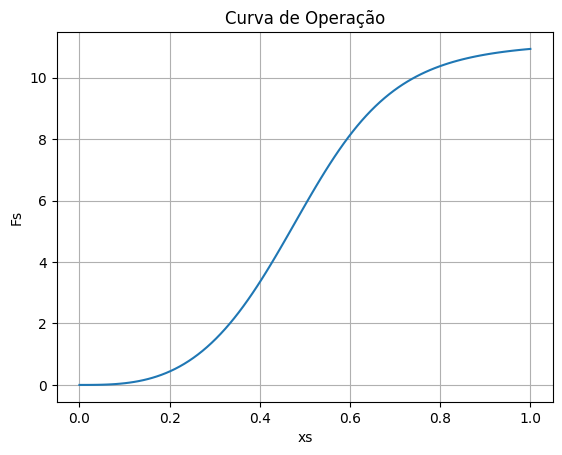

In [20]:
plt.plot(xs,ss(xs))
plt.ylabel('Fs')
plt.xlabel('xs')
plt.title('Curva de Operação')
plt.grid()

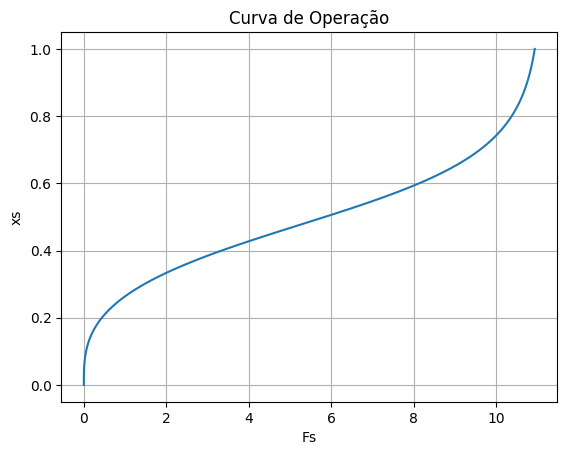

In [21]:
plt.plot(ss(xs),xs)
plt.ylabel('xs')
plt.xlabel('Fs')
plt.title('Curva de Operação')
plt.grid()

In [22]:
Fs = np.linspace(0,11)

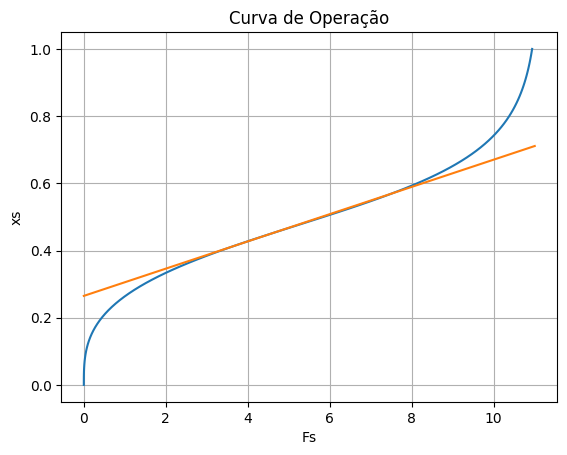

In [23]:
plt.plot(ss(xs),xs)
plt.plot(Fs, 0.04055*Fs+0.265)
plt.ylabel('xs')
plt.xlabel('Fs')
plt.title('Curva de Operação')
plt.grid()